# Field health from space: a guided, visual walk-through

This notebook repeats, step by step and on a map, exactly what the app's **geo-service** does when you press
*See this field from space* (`geo-service/field_health.py`, explained in `docs/FIELD_HEALTH.md`).

**Before you start**
- Earth Engine access for the project (see `docs/GEE_SETUP.md`, steps 1–2: `gcloud auth application-default login …`).
- Install once: `.venv\Scripts\python -m pip install -r geo-service/requirements-notebook.txt`.
- Open this notebook with the project's `.venv` Python as the kernel.

The field used below is a public test point in farmland near Mullanpur Dakha (Punjab). Change `LAT`/`LON`
to look at another field.

In [1]:
import sys
from datetime import date, timedelta
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # geo-service/, so we use the service's own code
import ee
import app                     # geo-service/app.py: same sign-in as the service (no key file)
import field_health as fh     # the exact computation the service runs

app.init_earth_engine()
print('Earth Engine ready, project:', app.PROJECT)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine ready, project: plant-disease-503711


## 1. The field and its neighbourhood

Without a mapped field boundary the service treats the field as a **30 m circle** around the point
(about 0.28 ha, ~28 Sentinel-2 pixels of 10 m × 10 m). The **neighbourhood** is a ring from 100 m to 1 km
around it; only pixels that ESA WorldCover marks as **cropland** (class 40) count, so roads, villages and
trees don't pull the comparison down.

In [2]:
LAT, LON = 30.858816, 75.666131
END = date(2026, 9, 26)
DAYS = 120
START = END - timedelta(days=DAYS)

point = ee.Geometry.Point([LON, LAT])
field, source = fh.field_geometry(LAT, LON)
ring = point.buffer(fh.RING_OUTER_M).difference(point.buffer(fh.RING_INNER_M), 1)
cropland = ee.ImageCollection(fh.WORLDCOVER).first().select('Map').eq(fh.CROPLAND)

area_field, area_ring, crop_share = ee.List([
    field.area(1), ring.area(1),
    cropland.reduceRegion(ee.Reducer.mean(), ring, 10).get('Map'),
]).getInfo()
print(f'field ({source}): {area_field/10000:.2f} ha | ring: {area_ring/1e6:.2f} km² | cropland in ring: {crop_share:.0%}')

field (buffer_30m): 0.28 ha | ring: 3.07 km² | cropland in ring: 72%


## 2. Sentinel-2 and the cloud problem

`COPERNICUS/S2_SR_HARMONIZED` is surface reflectance from the two Sentinel-2 satellites: a new picture of
the same place about every **5 days**. Each image comes with a **Scene Classification (SCL)** band that labels
every pixel. The service only trusts classes **4 vegetation, 5 bare soil, 6 water** (a flooded paddy is still
the field) and **7 unclassified**; clouds (8, 9), thin cirrus (10), cloud shadow (3) and the rest are masked.
A date is used only if **≥ 60 %** of the field is clear. In kharif (monsoon) many dates fail this; the service
reports that instead of guessing.

In [3]:
images = (ee.ImageCollection(fh.S2).filterBounds(field)
          .filterDate(START.isoformat(), (END + timedelta(days=1)).isoformat()))
print('Sentinel-2 images of this field in the window:', images.size().getInfo())

def clear_share(img):
    clear = img.select('SCL').remap(fh.CLEAR_SCL, [1] * len(fh.CLEAR_SCL), 0)
    return img.set('field_clear', clear.reduceRegion(ee.Reducer.mean(), field, 10).get('remapped'))

with_clear = images.map(clear_share)
best = with_clear.filter(ee.Filter.gte('field_clear', fh.MIN_CLEAR)).sort('system:time_start', False).first()
print('latest clear image:', ee.Date(best.get('system:time_start')).format('YYYY-MM-dd').getInfo())

Sentinel-2 images of this field in the window: 31


latest clear image: 2026-09-25


## 3. Look at it on a map

Layers (toggle them in the top-right control): true colour, **NDVI**, the SCL clear mask, the WorldCover
cropland mask, the field circle and the neighbourhood ring.

In [4]:
import geemap

idx = fh._indices(best, with_redsi=False)
clear = best.select('SCL').remap(fh.CLEAR_SCL, [1] * len(fh.CLEAR_SCL), 0)

m = geemap.Map(center=[LAT, LON], zoom=15)
m.add_basemap('SATELLITE')
m.addLayer(best, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}, 'Sentinel-2 true colour')
m.addLayer(idx.select('ndvi'), {'min': 0, 'max': 0.9, 'palette': ['#8c510a', '#f6e8c3', '#5ab4ac', '#01665e']}, 'NDVI')
m.addLayer(clear.selfMask(), {'palette': ['#00ff00']}, 'clear pixels (SCL 4-7)', False)
m.addLayer(cropland.selfMask(), {'palette': ['#ffcc00']}, 'WorldCover cropland', False)
m.addLayer(ee.FeatureCollection([ee.Feature(ring)]).style(color='yellow', fillColor='00000000'), {}, 'neighbourhood ring 100 m-1 km')
m.addLayer(ee.FeatureCollection([ee.Feature(field)]).style(color='red', fillColor='00000000', width=2), {}, 'field (30 m circle)')
m

Map(center=[30.858816, 75.666131], controls=(WidgetControl(options=['position', 'transparent_bg'], position='t…

## 4. The indices

| Index | Sentinel-2 bands | Formula | What it tells |
|---|---|---|---|
| **NDVI** | B8 (842 nm NIR, 10 m), B4 (665 nm red, 10 m) | (B8 − B4) / (B8 + B4) | green biomass / canopy cover; saturates around 0.8–0.9 in dense crops |
| **NDRE** | B8A (865 nm narrow NIR, 20 m), B5 (705 nm red-edge, 20 m) | (B8A − B5) / (B8A + B5) | leaf chlorophyll; still changes when NDVI has saturated |
| **REDSI** (wheat, experimental) | B4, B5, B7 (783 nm) | ((705−665)(B7−B4) − (783−665)(B5−B4)) / (2·B4) | yellow-rust stress; **lower = more stress** (Zheng et al., *Sensors* 2018, 18(3):868) |

Healthy green leaves absorb red light and reflect near-infrared; stressed or sparse crops do less of both,
so the indices drop. **They show stress, not which disease** – that is what the leaf photo is for.

In [5]:
raw, source = fh.query_rows(LAT, LON, START, END, with_redsi=False)   # ONE Earth Engine request
result = fh.summarize(raw, start=START, end=END, geometry_source=source)
print(result['summary'])
print(f"{result['clear_images']} of {result['images']} images clear; last clear: {result['last_clear_date']}")
print(f"{'date':12s}{'clear':>6s}{'NDVI':>7s}{'NDRE':>7s}   neighbours NDVI p25 / p50 / p75     z")
for r in result['series']:
    nb = r['neighbours']['ndvi']
    if r['used']:
        print(f"{r['date']:12s}{r['clear_fraction']:6.0%}{r['ndvi']:7.2f}{r['ndre']:7.2f}   {nb[0]:.2f} / {nb[1]:.2f} / {nb[2]:.2f}   {r['z']}")
    else:
        print(f"{r['date']:12s}{r['clear_fraction']:6.0%}   (cloudy, skipped)")

In line with nearby fields.
16 of 31 images clear; last clear: 2026-09-25
date         clear   NDVI   NDRE   neighbours NDVI p25 / p50 / p75     z
2026-05-31    100%   0.82   0.65   0.13 / 0.25 / 0.67   1.42
2026-06-05    100%   0.70   0.52   0.13 / 0.24 / 0.60   1.35
2026-06-07    100%   0.63   0.49   0.13 / 0.22 / 0.54   1.35
2026-06-10    100%   0.47   0.35   0.12 / 0.19 / 0.43   1.2
2026-06-15      0%   (cloudy, skipped)
2026-06-20    100%   0.09   0.09   0.09 / 0.17 / 0.43   -0.3
2026-06-25      0%   (cloudy, skipped)
2026-06-27     90%   0.08   0.03   0.12 / 0.25 / 0.43   -0.76
2026-06-30      0%   (cloudy, skipped)
2026-07-05     49%   (cloudy, skipped)
2026-07-10    100%   0.28   0.07   0.22 / 0.37 / 0.53   -0.41
2026-07-15    100%   0.33   0.12   0.31 / 0.47 / 0.64   -0.59
2026-07-20      0%   (cloudy, skipped)
2026-07-25      0%   (cloudy, skipped)
2026-07-27      0%   (cloudy, skipped)
2026-07-30      0%   (cloudy, skipped)
2026-08-04      0%   (cloudy, skipped)
2026-08-09  

## 5. The same chart the app draws

The shaded band is the **middle half of the neighbouring cropland pixels** (25th–75th percentile) on each clear
date. The service's verdict uses a *robust z-score*: `(field NDVI − neighbours' median) / (IQR / 1.349)`.
IQR/1.349 estimates the spread like a standard deviation, but a few odd pixels (a tree line, a road) can't
distort it. Two or more clear dates in a row at z ≤ −1 ⇒ *below neighbours since …*; one ⇒ *wait for the next
clear image*.

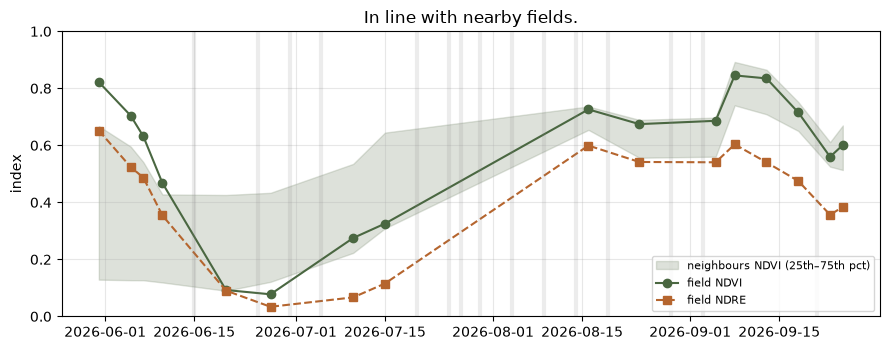

grey stripes = cloudy dates that were skipped


In [6]:
import matplotlib.pyplot as plt
from datetime import datetime

used = [r for r in result['series'] if r['used']]
cloudy = [r for r in result['series'] if not r['used']]
d = [datetime.fromisoformat(r['date']) for r in used]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.fill_between(d, [r['neighbours']['ndvi'][0] for r in used], [r['neighbours']['ndvi'][2] for r in used],
                color='#7A8B6F', alpha=0.25, label='neighbours NDVI (25th–75th pct)')
ax.plot(d, [r['ndvi'] for r in used], 'o-', color='#4A6741', label='field NDVI')
ax.plot(d, [r['ndre'] for r in used], 's--', color='#B5652E', label='field NDRE')
for r in cloudy:
    ax.axvline(datetime.fromisoformat(r['date']), color='grey', alpha=0.15, lw=3)
ax.set_ylim(0, 1); ax.set_ylabel('index'); ax.set_title(result['summary'])
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('grey stripes = cloudy dates that were skipped')

## What to try next
- Change `LAT`, `LON` to another field, or `END` to a monsoon month (July–August) and watch most dates become
  "cloudy, skipped" – that is why the app says *no clear image since …* instead of inventing a number.
- For a wheat field in Feb–Mar, pass `with_redsi=True` to `fh.query_rows` and look at the REDSI column.
- Limits to keep in mind: a 30 m circle can include the edge of a neighbouring field; 10 m pixels cannot see
  individual plants; a field that was sown later than its neighbours looks "below" until it catches up.